# Stage-3 Generation & Critic Stats

Comprehensive notebook to inspect the Stage-3 data flywheel: raw generation logs, critic scores, consolidated datasets, and summary files. Use it after each long tmux run to verify quality drift, rhyme density, and critic coverage.

## Setup
Update paths below if you keep multiple configs. By default the notebook resolves everything via `config/rapbot.yaml`.

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')

REPO_ROOT = Path('..').resolve()
CONFIG_PATH = REPO_ROOT / 'config' / 'rapbot.yaml'
DEFAULT_LOG = REPO_ROOT / 'data' / 'generated_raw.jsonl'
DEFAULT_CRITIC = REPO_ROOT / 'data' / 'critic_scores.jsonl'
DEFAULT_SCORED = REPO_ROOT / 'data' / 'scored_dataset.jsonl'
DEFAULT_SUMMARY = REPO_ROOT / 'data' / 'stats' / 'stage3_summary.json'

try:
    import yaml  # type: ignore
except Exception:
    yaml = None

cfg = {}
if CONFIG_PATH.exists() and yaml is not None:
    with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f) or {}

paths_cfg = cfg.get('paths', {})
stats_cfg = cfg.get('stats', {})

def resolve(path_value, fallback):
    if path_value is None:
        return fallback
    p = Path(path_value)
    if not p.is_absolute():
        p = REPO_ROOT / p
    return p

LOG_PATH = resolve(paths_cfg.get('generation_log_path'), DEFAULT_LOG)
CRITIC_PATH = resolve(paths_cfg.get('critic_scores_path'), DEFAULT_CRITIC)
if not CRITIC_PATH.exists():
    CRITIC_PATH = DEFAULT_CRITIC
SCORED_PATH = resolve(paths_cfg.get('scored_dataset_path'), DEFAULT_SCORED)
SUMMARY_PATH = resolve(stats_cfg.get('summary_path'), DEFAULT_SUMMARY)

print('Log file   :', LOG_PATH)
print('Critic file:', CRITIC_PATH)
print('Scored file:', SCORED_PATH)
print('Summary    :', SUMMARY_PATH)


Log file   : /workspace/rap-botV4/data/generated_raw.jsonl
Critic file: /workspace/rap-botV4/data/critic_scores.jsonl
Scored file: /workspace/rap-botV4/data/scored_dataset.jsonl
Summary    : /workspace/rap-botV4/data/stats/stage3_summary.json


In [2]:
def read_jsonl(path: Path):
    records = []
    if not path.exists():
        return records
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

logs = pd.DataFrame(read_jsonl(LOG_PATH))
critic = pd.DataFrame(read_jsonl(CRITIC_PATH))
scored = pd.DataFrame(read_jsonl(SCORED_PATH))
summary_meta = json.load(open(SUMMARY_PATH)) if SUMMARY_PATH.exists() else {}

print(f"Loaded logs={len(logs):,} critic={len(critic):,} scored={len(scored):,}")


Loaded logs=862 critic=862 scored=862


In [3]:
if not scored.empty:
    critic_norm = pd.json_normalize(scored['critic']) if 'critic' in scored else pd.DataFrame()
    critic_norm = critic_norm.add_prefix('critic.')
    gen_norm = pd.json_normalize(scored['generation']) if 'generation' in scored else pd.DataFrame()
    gen_norm = gen_norm.add_prefix('generation.')
    scored_flat = pd.concat([scored.drop(columns=[col for col in ['critic', 'generation'] if col in scored]), critic_norm, gen_norm], axis=1)
else:
    scored_flat = pd.DataFrame()

scored_flat['verse_len'] = scored_flat['bars'].apply(lambda bars: len(bars) if isinstance(bars, list) else np.nan)
scored_flat['timestamp'] = pd.to_datetime(scored_flat['generation.timestamp'], errors='coerce') if 'generation.timestamp' in scored_flat else pd.NaT

print('Flattened columns:', scored_flat.columns.tolist()[:10], '...')


Flattened columns: ['verse_id', 'artist', 'seed', 'scheme', 'verse_score', 'accepted', 'bars', 'bar_metrics', 'verse_text', 'critic.overall_score'] ...


In [4]:
overview = {
    'total_logs': len(logs),
    'total_scored': len(scored_flat),
    'accept_rate': scored_flat['accepted'].mean() if 'accepted' in scored_flat else float('nan'),
    'avg_overall': scored_flat['critic.overall_score'].mean() if 'critic.overall_score' in scored_flat else float('nan'),
    'avg_depth': scored_flat['critic.depth_score'].mean() if 'critic.depth_score' in scored_flat else float('nan'),
    'avg_coherence': scored_flat['critic.coherence_score'].mean() if 'critic.coherence_score' in scored_flat else float('nan'),
    'avg_originality': scored_flat['critic.originality_score'].mean() if 'critic.originality_score' in scored_flat else float('nan'),
    'avg_verse_score': scored_flat['verse_score'].mean() if 'verse_score' in scored_flat else float('nan'),
}
display(pd.DataFrame([overview]))

if summary_meta:
    print('> Summary snapshot from consolidate_stage3:')
    display(pd.DataFrame(summary_meta.get('score_summary', {})).T)


,total_logs,total_scored,accept_rate,avg_overall,avg_depth,avg_coherence,avg_originality,avg_verse_score
0,862,862,0.737819,2.022042,2.352668,2.412413,2.166473,0.434713


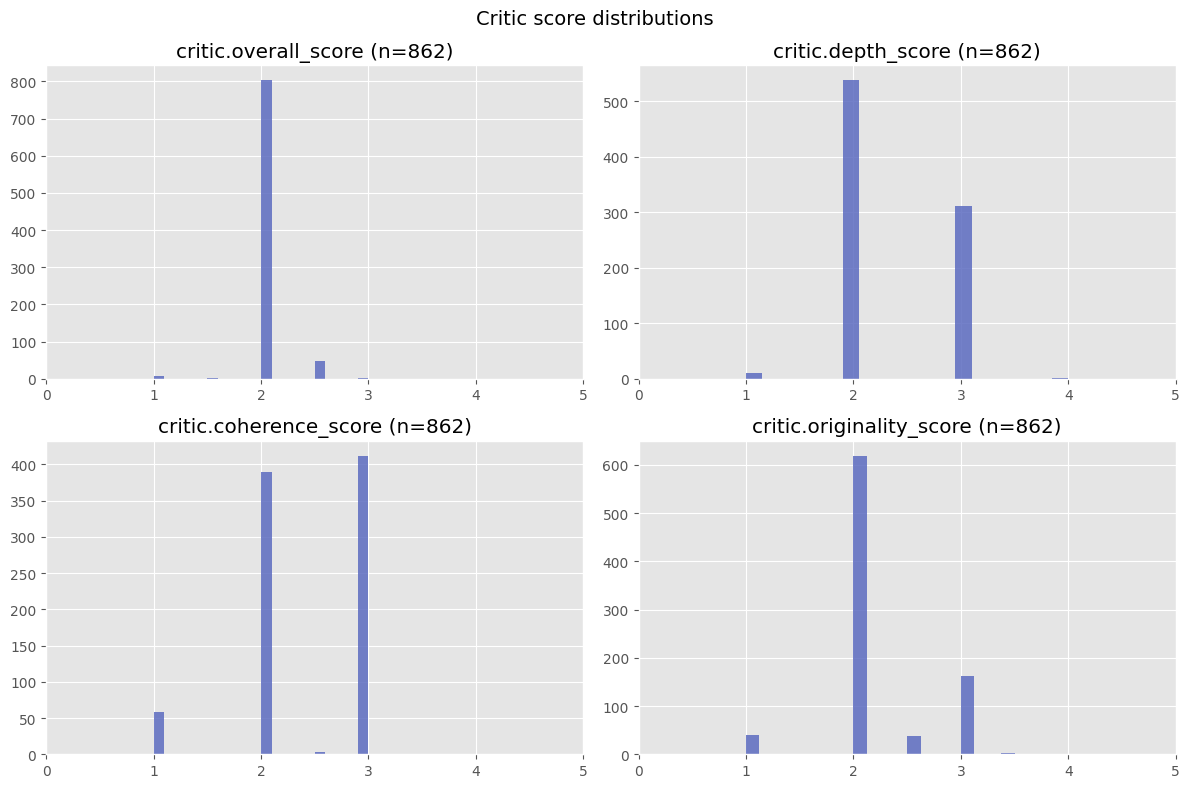

In [5]:
if not scored_flat.empty:
    fields = ['critic.overall_score', 'critic.depth_score', 'critic.coherence_score', 'critic.originality_score']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, field in zip(axes.flat, fields):
        if field not in scored_flat:
            ax.set_visible(False)
            continue
        data = scored_flat[field].dropna()
        ax.hist(data, bins=20, color='#5c6bc0', alpha=0.85)
        ax.set_title(f'{field} (n={len(data)})')
        ax.set_xlim(0, 5)
    fig.suptitle('Critic score distributions', fontsize=14)
    plt.tight_layout()


In [6]:
if not scored_flat.empty:
    seed_summary = (
        scored_flat.groupby('seed')
        .agg(
            count=('verse_id', 'count'),
            avg_overall=('critic.overall_score', 'mean'),
            avg_depth=('critic.depth_score', 'mean'),
            avg_verse_score=('verse_score', 'mean'),
            accept_rate=('accepted', 'mean'),
        )
        .sort_values('avg_overall', ascending=False)
    )
    display(seed_summary.head(10))
    display(seed_summary.tail(10))


,count,avg_overall,avg_depth,avg_verse_score,accept_rate
seed,,,,,
smoldering punchlines cooling on alloy workbenches,10,2.150000,3.000000,0.450101,0.800000
villain’s ledger coated in graphite and burnt ozone,10,2.150000,2.600000,0.418208,0.800000
metal fingers calibrating fractured loops in the furnace,17,2.117647,2.470588,0.433883,0.823529
covert mechanisms plotting syncopated sabotage,11,2.090909,2.363636,0.372963,0.727273
forgotten mixtapes whispering secrets to the villain,17,2.088235,2.176471,0.445435,0.823529
adversarial metrics plotted across stained graph paper,17,2.088235,2.882353,0.499643,0.823529
lab rats scurrying past reels soaked in bass residue,12,2.083333,2.000000,0.381494,0.666667
rusted synth wires tangled in a notebook of ciphers,20,2.075000,2.600000,0.393867,0.700000
vectors of rhyme spiraling from a dented steel mask,14,2.071429,2.357143,0.529298,1.000000


,count,avg_overall,avg_depth,avg_verse_score,accept_rate
seed,,,,,
krylon fumes and comic books on the table,21,2.000000,2.000000,0.575974,0.952381
mask fogged from the heat of molten rhyme compounds,20,2.000000,2.400000,0.403442,0.700000
villainous specter soldering cadences to circuitry,24,2.000000,2.083333,0.381529,0.583333
malfunctioning compressors muttering masked riddles,21,2.000000,2.333333,0.328526,0.285714
volatile rhyme cocktails bubbling inside glass flasks,20,2.000000,2.400000,0.383442,0.700000
voltage streams weaving multis like braided wire,26,1.961538,1.961538,0.396025,0.538462
harmonic anomalies fluttering beneath jagged panels,21,1.952381,2.904762,0.409922,0.619048
villain’s profile flickering across a cracked CRT screen,10,1.950000,1.900000,0.455939,0.800000
syntax reactors glowing between torn vinyl sleeves,18,1.944444,1.944444,0.449347,0.777778


/tmp/ipykernel_378158/3090318955.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


,critic.overall_score,samples,verse_score
timestamp,,,
2025-12-10 00:00:00+00:00,2.032787,61,0.435551
2025-12-10 01:00:00+00:00,2.062500,72,0.490646
2025-12-10 02:00:00+00:00,2.000000,75,0.459950
2025-12-10 03:00:00+00:00,2.018987,79,0.398553
2025-12-10 04:00:00+00:00,2.000000,73,0.442010


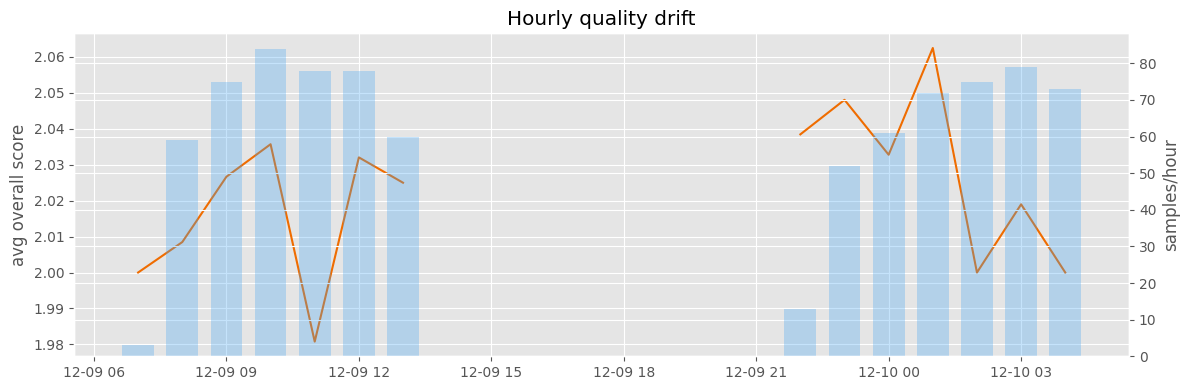

In [7]:
if 'timestamp' in scored_flat and not scored_flat['timestamp'].isna().all():
    timeline = (
        scored_flat.set_index('timestamp')
        .resample('1H')
        .agg({'critic.overall_score': 'mean', 'verse_id': 'count', 'verse_score': 'mean'})
        .rename(columns={'verse_id': 'samples'})
    )
    display(timeline.tail())
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(timeline.index, timeline['critic.overall_score'], label='overall', color='#ef6c00')
    ax1.set_ylabel('avg overall score')
    ax2 = ax1.twinx()
    ax2.bar(timeline.index, timeline['samples'], alpha=0.3, width=0.03, label='samples/hour', color='#42a5f5')
    ax2.set_ylabel('samples/hour')
    plt.title('Hourly quality drift')
    plt.tight_layout()


In [8]:
def explode_bar_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if df.empty or 'bar_metrics' not in df:
        return pd.DataFrame()
    for _, row in df.iterrows():
        metrics = row.get('bar_metrics') or []
        for metric in metrics:
            metric = metric or {}
            metric['verse_id'] = row['verse_id']
            metric['letter'] = metric.get('letter')
            rows.append(metric)
    return pd.DataFrame(rows)

bar_df = explode_bar_metrics(scored_flat)
if not bar_df.empty:
    stats = bar_df[['final_score', 'meter_score', 'struct_score', 'length']].describe()
    display(stats)


,final_score,meter_score,struct_score,length
count,13587.000000,1.358700e+04,13587.000000,13587.000000
mean,-2.481416,3.684642e-01,1.832052,16.038051
std,2.706223,4.081217e-01,1.970314,6.554897
min,-10.387604,2.572209e-56,-1.655148,1.000000
25%,-4.553082,2.046972e-16,0.000000,11.000000
50%,-3.335675,1.353353e-01,1.528149,13.000000
75%,-0.440347,8.824969e-01,3.547507,23.000000
max,8.324136,1.000000e+00,8.637703,32.000000


### Notes
- The `seed_summary` table surfaces which prompts lead to the best critic scores.
- The timeline plot helps spot degradation when running overnight tmux jobs.
- Re-run this notebook after `score_with_openai.py`, `consolidate_stage3.py`, and `train_local_critic.py` to confirm the data feeding LoRA fine-tunes looks healthy.
